# Hydrogen atom using Gausslet orbitals

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

from hydrogen_atom import (
    hydrogen_atom_groundstate_gausslets,
    evaluate_gausslet_wavefunction)

In [2]:
# Gausslet G10 coefficients
import sys
sys.path.append("../gausslets/")
from gausslets import get_gausslet_g10_coeffs
gausslet_coeffs, gausslet_indices = get_gausslet_g10_coeffs()

In [3]:
# list of grid dimensions along each coordinate direction
grid_dims = [9, 11, 13]

In [4]:
# list of grid scaling factors
scaling_list = [i / 40 for i in range(32, 61)]

In [5]:
en0_table  = {}
psi0_table = {}
for d in grid_dims:
    en0_table[d], psi0_table[d] = \
        hydrogen_atom_groundstate_gausslets(gausslet_coeffs, d, scaling_list, tol_nuc=1e-5)

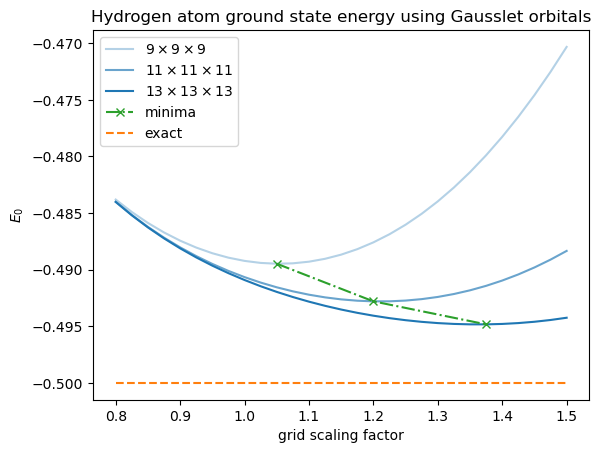

In [6]:
# visualize computed ground state energy in dependence of the scaling factor,
# for various grid dimensions
idx_min = {}
for d in grid_dims:
    idx_min[d] = int(np.argmin(en0_table[d]))
for i, d in enumerate(grid_dims):
    plt.plot(scaling_list, en0_table[d], color="tab:blue", alpha=(i+1)/len(grid_dims),
             label=rf"${d} \times {d} \times {d}$")
plt.plot([scaling_list[idx_min[d]] for d in grid_dims],
         [en0_table[d][idx_min[d]] for d in grid_dims], 'x-.',
         color="tab:green", label="minima")
plt.plot(scaling_list, len(scaling_list) * [-0.5], '--', color="tab:orange", label="exact")
plt.xlabel("grid scaling factor")
plt.ylabel(r"$E_0$")
plt.legend()
plt.title("Hydrogen atom ground state energy using Gausslet orbitals")
plt.savefig("hydrogen_atom_energy.pdf")
plt.show()

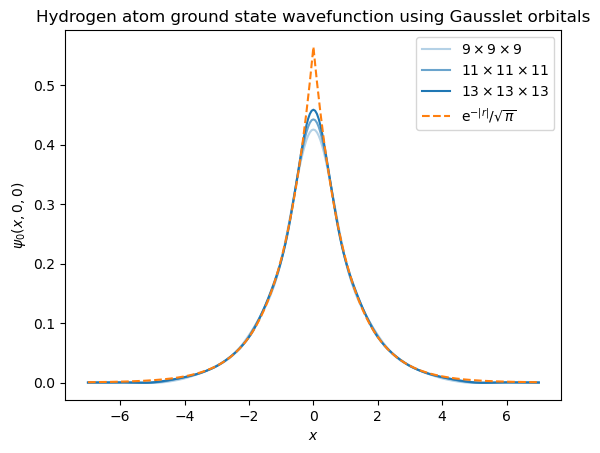

In [7]:
# visualize ground state wavefunction
max_extent = (max(grid_dims) - 1) // 2
x_path = np.linspace(-(max_extent + 1), max_extent + 1, 257)
psi0_real = {}
for i, d in enumerate(grid_dims):
    idx_min = int(np.argmin(en0_table[d]))
    extent = (d - 1) // 2
    grid = [
        (-extent, d),  # x
        (-extent, d),  # y
        (-extent, d),  # z
    ]
    scaling = scaling_list[idx_min]
    psi_x00 = np.array([evaluate_gausslet_wavefunction(
                            gausslet_coeffs, gausslet_indices, grid, scaling,
                            psi0_table[d][idx_min], [x, 0, 0])
                        for x in x_path])
    if psi_x00[len(x_path) // 2] < 0:
        psi_x00 = -psi_x00
    plt.plot(x_path, psi_x00, color="tab:blue", alpha=(i+1)/len(grid_dims),
             label=rf"${d} \times {d} \times {d}$")
    psi0_real[d] = psi_x00
plt.plot(x_path, np.exp(-np.abs(x_path)) / np.sqrt(np.pi), '--',
         color="tab:orange", label=r"$\mathrm{e}^{-|r|} / \sqrt{\pi}$")
plt.legend()
plt.xlabel(r"$x$")
plt.ylabel(r"$\psi_0(x, 0, 0)$")
plt.title("Hydrogen atom ground state wavefunction using Gausslet orbitals")
plt.savefig("hydrogen_atom_wavefunction.pdf")
plt.show()

In [8]:
# save data to disk
with h5py.File("hydrogen_atom.hdf5", "w") as file:
    file.attrs["grid_dims"] = grid_dims
    file.attrs["scaling_list"] = scaling_list
    file.attrs["x_path"] = x_path
    for d in grid_dims:
        file[f"en0_{d}"]  = en0_table[d]
        file[f"psi0_{d}"] = psi0_table[d]
        file[f"psi0_real_{d}"] = psi0_real[d]